# TT-24 — PCA: nén 561 tín hiệu cảm biến cho thiết bị đeo

**Bài toán.** Vòng đeo tay nhận biết 6 hoạt động (đi bộ, lên/xuống cầu thang, ngồi, đứng, nằm) từ **561 đặc trưng**
dẫn xuất từ gia tốc kế và con quay. Chip chỉ có **64 KB RAM** và pin phải trụ 7 ngày. Câu hỏi: PCA nén xuống bao
nhiêu chiều thì vẫn giữ được độ chính xác, và **tiết kiệm được gì thật sự**?

**Cấu trúc code.**
* `src/data.py`: tải dữ liệu UCI HAR, đổi tên 42 cột trùng, cache parquet, chia train/test **theo người**.
* `src/pca_pipeline.py`: mỗi bước của đề là một hàm `run_*()`. Hàm nhận dữ liệu, ghi CSV/PNG vào `reports/`,
  trả về DataFrame.

Notebook này gọi lại đúng các hàm đó (nên số liệu ở đây và `reports/` là một). Trước mỗi ô có giải thích **logic
code**: làm gì, vì sao làm thế.

**3 nguyên tắc chống rò rỉ áp dụng xuyên suốt:**
1. Giữ cách chia **theo người** của bộ gốc (21 người train, 9 người test).
2. `StandardScaler` và `PCA` nằm **trong `Pipeline`**, nên chỉ được fit trên dữ liệu train của từng lần fit.
3. **Mọi lựa chọn** (số chiều K) làm bằng `GroupKFold(5)` theo người trên train. Tập test chỉ để **báo cáo**.

In [1]:
%matplotlib inline
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path("..").resolve() / "src"))

import numpy as np
import pandas as pd
from IPython.display import Image, display

import data as D
import pca_pipeline as P

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.width", 180)
R = P.REPORTS_DIR

## 1–2. Nạp dữ liệu, giữ cách chia theo người, kiểm tra thang đo

**Logic code (`data.split_by_subject`):** bộ gốc đã chia sẵn `train/` và `test/` theo người. Code ghép thành một
bảng có cột `split` và `subject`, rồi tách lại đúng như gốc. Có `assert` kiểm tra hai tập không chung người nào:

```python
overlap = set(tr["subject"]) & set(te["subject"])
assert not overlap
```

**Vì sao quan trọng:** nếu trộn rồi chia ngẫu nhiên, cùng một người có mặt ở cả train và test. Model sẽ học
"dáng đi của anh A" thay vì "dáng đi bộ", và accuracy test bị thổi phồng.

`groups` (mã người của từng dòng train) được giữ lại để dùng cho `GroupKFold` ở các bước sau.

In [2]:
df, Xtr, Xte, ytr, yte, groups, feats = P.load()
display(df.groupby(["split", "activity"]).size().unstack(0))
print("So nguoi train:", len(set(groups)), "| so cot:", len(feats))

[TT-24]   Train (7352, 561) (21 nguoi) | Test (2947, 561) (9 nguoi) | khong nguoi nao o ca 2 tap


[TT-24]   Gia tri trong [-1, 1] nhung phuong sai cot tu 0.0017 den 0.565 (gap 339 lan) -> van phai StandardScaler


split,test,train
activity,,
LAYING,537,1407
SITTING,491,1286
STANDING,532,1374
WALKING,496,1226
WALKING_DOWNSTAIRS,420,986
WALKING_UPSTAIRS,471,1073


So nguoi train: 21 | so cot: 561


**Đọc kết quả:** 7.352 cửa sổ train (21 người) và 2.947 cửa sổ test (9 người), 6 lớp khá cân bằng (986–1.407 mẫu/lớp
ở train). Dữ liệu đã nằm trong [−1, 1], **nhưng phương sai từng cột chênh nhau 339 lần** (0,0017 đến 0,565). PCA tìm
hướng có phương sai lớn nhất, nên nếu không chuẩn hoá thì các cột phương sai lớn sẽ chiếm trọn các thành phần đầu.
Đây là lý do vẫn phải `StandardScaler` dù dữ liệu "đã chuẩn hoá sẵn".

## 3–5. Scree plot, phương sai tích luỹ, bảng ngưỡng → số chiều

**Logic code (`run_variance_analysis`):**

```python
scaler   = StandardScaler().fit(Xtr)                    # fit CHỈ trên train
pca_full = PCA().fit(scaler.transform(Xtr))             # giữ đủ 561 thành phần
cum      = np.cumsum(pca_full.explained_variance_ratio_)
k        = np.argmax(cum >= nguong) + 1                 # K nhỏ nhất đạt ngưỡng
```

`explained_variance_ratio_[i]` là tỉ lệ phương sai thành phần i giữ được. Cộng dồn lên thì ra đường tích luỹ.
`argmax(cum >= t)` trả về chỉ số đầu tiên đạt ngưỡng (cộng 1 vì đếm từ 0). Hàm cũng fit thêm một PCA **không
chuẩn hoá** để so sánh.

[TT-24]   PC1 giu 50.8%, PC2 6.6%, PC3 2.8% phuong sai (co chuan hoa); khong chuan hoa: PC1 62.6%


[TT-24]     80%: can  26 chieu (giam 95.4%) | khong chuan hoa:  10


[TT-24]     90%: can  63 chieu (giam 88.8%) | khong chuan hoa:  34


[TT-24]     95%: can 102 chieu (giam 81.8%) | khong chuan hoa:  67


[TT-24]     99%: can 179 chieu (giam 68.1%) | khong chuan hoa: 155


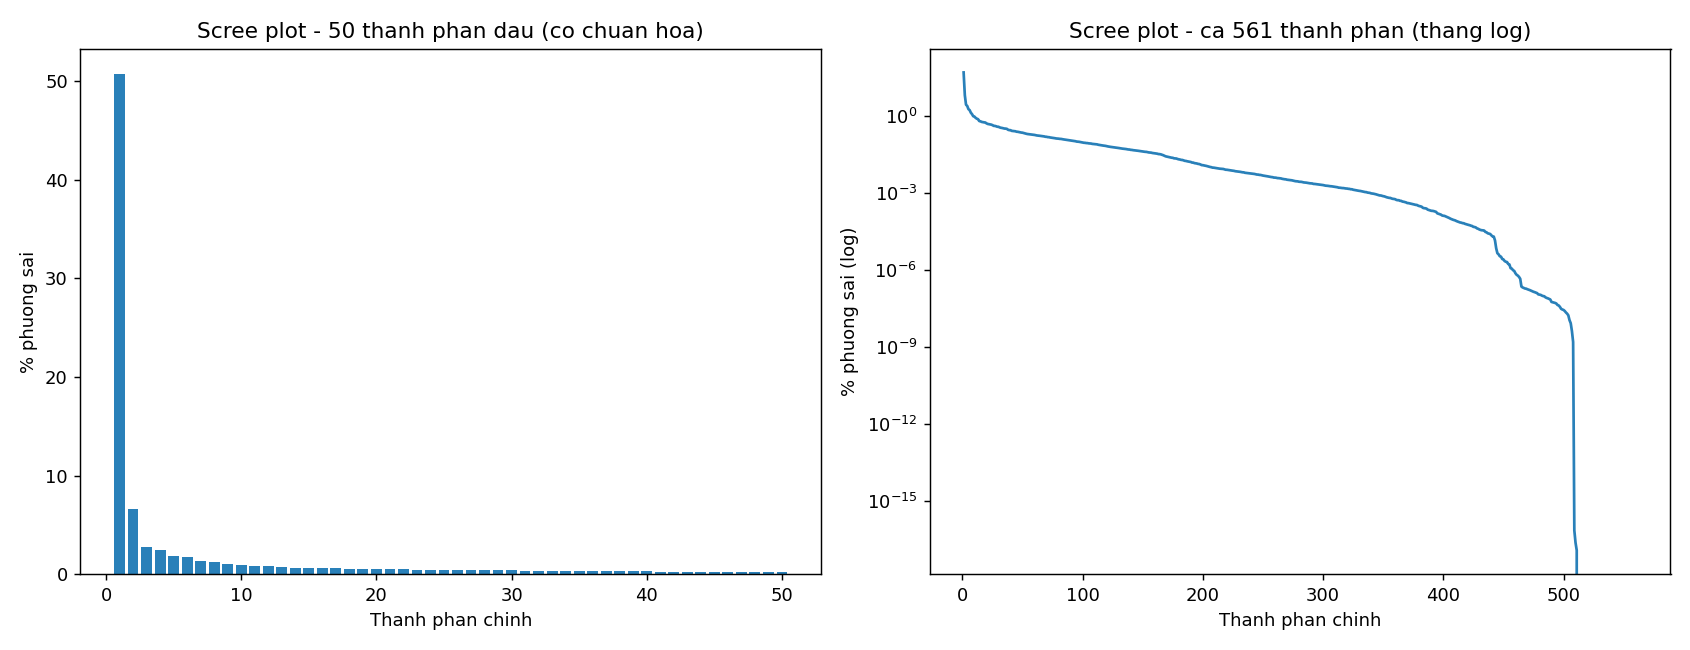

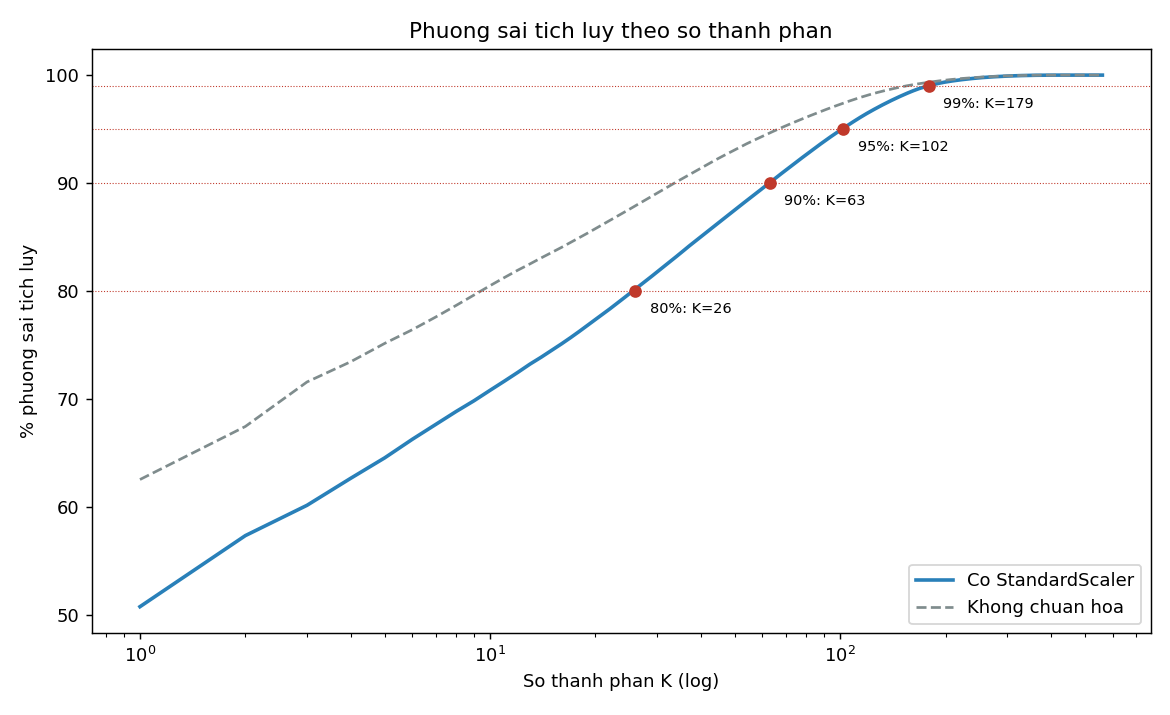

,nguong_phuong_sai,so_chieu_co_chuan_hoa,giam_chieu_%,so_chieu_khong_chuan_hoa,giam_chieu_khong_chuan_hoa_%
0,0.8000,26,95.3654,10,98.2175
1,0.9000,63,88.7701,34,93.9394
2,0.9500,102,81.8182,67,88.0570
3,0.9900,179,68.0927,155,72.3708


In [3]:
scaler, pca_full, pca_raw, var_table = P.run_variance_analysis(Xtr)
k95 = int(var_table.loc[var_table.nguong_phuong_sai == 0.95, "so_chieu_co_chuan_hoa"].iloc[0])
display(Image(R / "scree_plot.png")); display(Image(R / "variance_tich_luy.png"))
var_table

**Đọc kết quả:**

| Ngưỡng phương sai | 80% | 90% | **95%** | 99% |
|---|---|---|---|---|
| Số chiều (có chuẩn hoá) | 26 | 63 | **102** | 179 |
| Giảm chiều | 95,4% | 88,8% | **81,8%** | 68,1% |
| Số chiều (không chuẩn hoá) | 10 | 34 | 67 | 155 |

* **PC1 một mình giữ 50,8%** phương sai, PC2 6,6%, PC3 2,8%. Scree plot có "khuỷu" rất sớm, sau đó là một đuôi dài
  các thành phần nhỏ dần đều. 561 cột thật ra nằm gần một không gian ít chiều hơn nhiều.
* "Mức tham chiếu" của đề (~60–70 thành phần cho 95%) **chỉ đúng khi không chuẩn hoá** (67). Có chuẩn hoá thì cần
  **102**. Không chuẩn hoá trông "nén tốt hơn" chỉ vì vài cột phương sai lớn chiếm hết các thành phần đầu
  (PC1 = 62,6%), không phải vì giữ được nhiều thông tin hơn.

## 6. ⭐ Thí nghiệm chính: đánh đổi số chiều vs accuracy và thời gian

**Logic code (`run_dimension_tradeoff` → `choose_sweet_spot`):** với mỗi K ∈ {2, 5, 10, 25, 50, 75, 100, 150, 200, 300,
400, 561}:

```python
pipe = Pipeline([("scale", StandardScaler()), ("pca", PCA(K)), ("clf", LinearSVC())])
cv   = cross_val_score(pipe, Xtr, ytr, groups=groups, cv=GroupKFold(5))   # 5 lần: 4/5 số người train, 1/5 kiểm tra
pipe.fit(Xtr, ytr); acc_test = pipe.score(Xte, yte)                        # chỉ ghi lại để báo cáo
```

* **Vì sao `GroupKFold`:** mỗi fold kiểm tra trên những **người chưa gặp**, giống tình huống thật (bán vòng tay cho
  người mới). `KFold` thường sẽ để cùng một người ở cả hai phía.
* Scaler và PCA nằm trong pipeline, nên ở mỗi fold chúng được **fit lại chỉ trên phần train của fold**.
* **Điểm ngọt** = K nhỏ nhất có `acc_cv ≥ acc_cv(561) − 1 điểm`. Quy tắc chỉ nhìn CV, **không nhìn test**.

[TT-24]     K=  2: phuong sai  57.4%  acc CV=0.4985+-0.036  test=0.5772  fit= 0.76s


[TT-24]     K=  5: phuong sai  64.6%  acc CV=0.7896+-0.038  test=0.7988  fit= 0.73s


[TT-24]     K= 10: phuong sai  70.8%  acc CV=0.8298+-0.051  test=0.8331  fit= 0.88s


[TT-24]     K= 25: phuong sai  79.8%  acc CV=0.8761+-0.051  test=0.8921  fit= 0.96s


[TT-24]     K= 50: phuong sai  87.5%  acc CV=0.8958+-0.049  test=0.9118  fit= 1.31s


...

[TT-24]     K=200: phuong sai  99.4%  acc CV=0.9230+-0.033  test=0.9515  fit= 7.79s


[TT-24]     K=300: phuong sai  99.9%  acc CV=0.9275+-0.035  test=0.9617  fit=22.82s


[TT-24]     K=400: phuong sai 100.0%  acc CV=0.9288+-0.037  test=0.9600  fit=34.57s


[TT-24]     K=561: phuong sai 100.0%  acc CV=0.9303+-0.037  test=0.9627  fit=51.50s


[TT-24]   => DIEM NGOT (CV): K=200 (acc CV 0.9230 vs 561 chieu 0.9303)


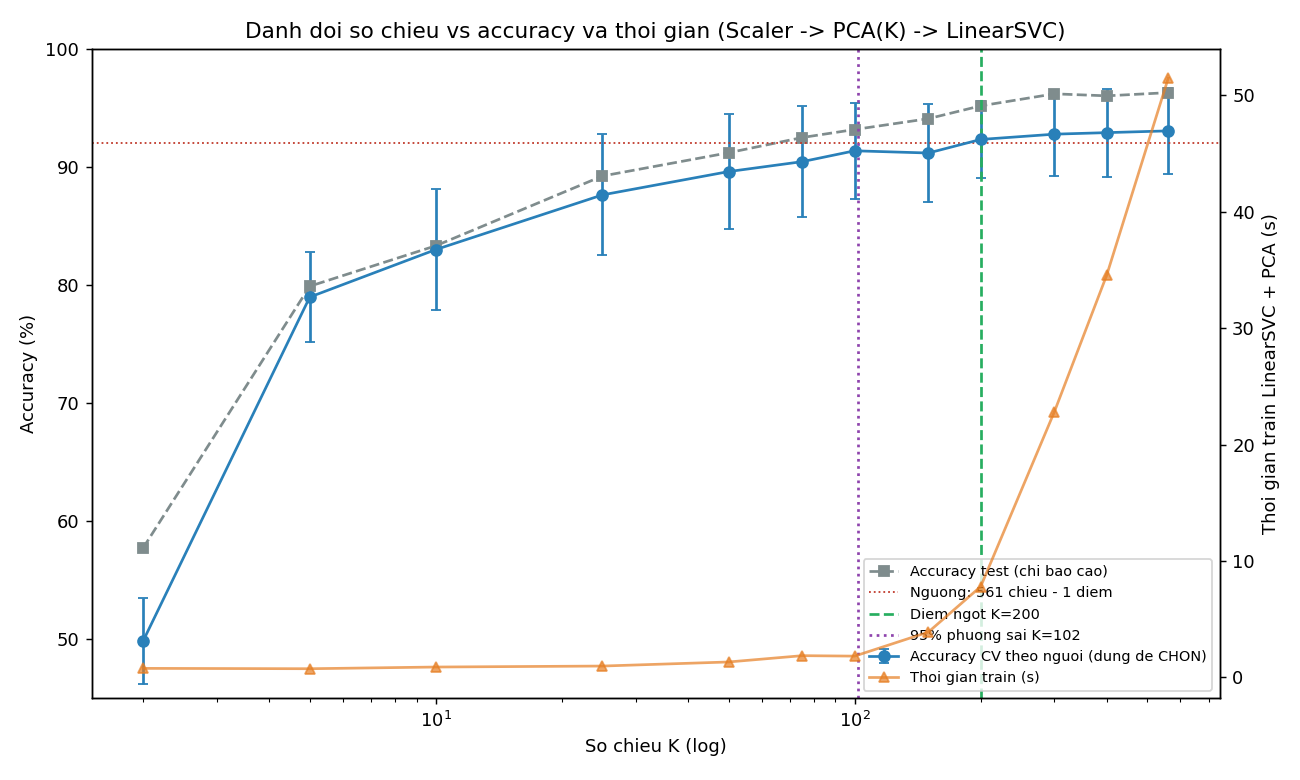

,K,giam_chieu_%,phuong_sai_giu_%,acc_cv,acc_cv_std,acc_test,thoi_gian_fit_s,thoi_gian_du_doan_ms_moi_mau,mat_acc_cv_vs_561_diem
0,2,99.6435,57.3619,0.4985,0.0363,0.5772,0.7618,0.0043,43.1832
1,5,99.1087,64.5605,0.7896,0.0383,0.7988,0.7310,0.0052,14.0693
2,10,98.2175,70.8156,0.8298,0.0514,0.8331,0.8771,0.0054,10.0471
3,25,95.5437,79.7595,0.8761,0.0511,0.8921,0.9613,0.0059,5.4184
4,50,91.0873,87.5184,0.8958,0.0489,0.9118,1.3114,0.0060,3.4463
5,75,86.6310,91.9548,0.9043,0.0467,0.9247,1.8535,0.0067,2.6038
6,100,82.1747,94.8915,0.9134,0.0407,0.9315,1.8144,0.0063,1.6858
7,150,73.2620,98.1054,0.9116,0.0419,0.9406,3.8809,0.0105,1.8738
8,200,64.3494,99.3636,0.9230,0.0330,0.9515,7.7909,0.0107,0.7254
9,300,46.5241,99.9099,0.9275,0.0353,0.9617,22.8233,0.0114,0.2791


In [4]:
tradeoff = P.run_dimension_tradeoff(Xtr, ytr, Xte, yte, groups)
k_sweet = P.choose_sweet_spot(tradeoff)
P.plot_tradeoff(tradeoff, k_sweet, k95)
display(Image(R / "danh_doi_chieu_accuracy.png"))
tradeoff

**Đọc kết quả** (accuracy CV theo người, ± độ lệch giữa 5 fold):

| K | 10 | 25 | 50 | 100 (≈ 95% phương sai) | 150 | **200** | 300 | 561 |
|---|---|---|---|---|---|---|---|---|
| Phương sai giữ | 70,8% | 79,8% | 87,5% | 94,9% | 98,1% | **99,4%** | 99,9% | 100% |
| Acc CV | 0,830 | 0,876 | 0,896 | 0,913 | 0,912 | **0,923** | 0,928 | 0,930 |
| Mất so với 561 | −10,1 | −5,4 | −3,5 | −1,7 | −1,9 | **−0,7** | −0,3 | 0 |

* **Điểm ngọt theo CV: K = 200** (giảm 64% số chiều, mất 0,7 điểm). Trên test: 0,9515 so với 0,9627 (−1,1 điểm).
* **Kỳ vọng của đề ("~60–70 chiều, mất < 1%") không đúng ở đây.** K = 50 mất 3,5 điểm, và ngay cả K = 102 (95% phương
  sai) vẫn mất 1,7 điểm. **Phương sai lớn ≠ thông tin phân loại**: các hướng phương sai nhỏ ở đuôi vẫn chứa tín hiệu
  phân biệt *ngồi* với *đứng* (xem mục 11).
* Độ lệch giữa các fold (±3,3–5,1 điểm) **lớn hơn nhiều** so với ngưỡng 1 điểm. Thứ tự giữa K = 100 và 150 đảo nhau là
  nhiễu (0,913 so với 0,912). Điểm ngọt nên đọc là "khoảng 150–300", không phải đúng 200.
* **Thời gian train** chỉ ~1–4 s tới K = 150, rồi tăng mạnh: ~8 s ở K = 200, ~51 s ở 561 (lần chạy notebook này; lần chạy
  script trước đo ~3 s và ~23 s, vì máy dao động, nhưng hình dạng đường như nhau). LinearSVC hội tụ chậm hơn
  nhiều khi số chiều lớn và các cột tương quan mạnh (bài toán tối ưu kém điều kiện hơn). Đây là khoản tiết kiệm thực
  khi train lại model trên máy chủ.

## 7. Scatter PC1–PC2 tô màu 6 hoạt động

**Logic code (`run_pc_scatter`):** chiếu train lên 2 thành phần đầu (`pca_full.transform(...)[:, :2]`) rồi vẽ. Để
**định lượng** thay vì chỉ nhìn, hàm còn: (a) chấm LinearSVC 6 lớp chỉ với 2 chiều (CV theo người); (b) chấm bài
nhị phân "động vs tĩnh" chỉ với **PC1** (Pipeline Scaler → PCA(1) → LogisticRegression).

[TT-24]   6 lop chi voi 2 chieu: acc CV=0.498; dong vs tinh chi voi PC1: CV=0.9965, test=0.9990


[TT-24]   PC1/PC2 trung binh theo hoat dong: WALKING=(+15.8,+1.0), WALKING_UPSTAIRS=(+12.9,-6.9), WALKING_DOWNSTAIRS=(+23.8,+2.1), SITTING=(-14.0,+1.0), STANDING=(-13.5,+0.2), LAYING=(-14.3,+1.7)


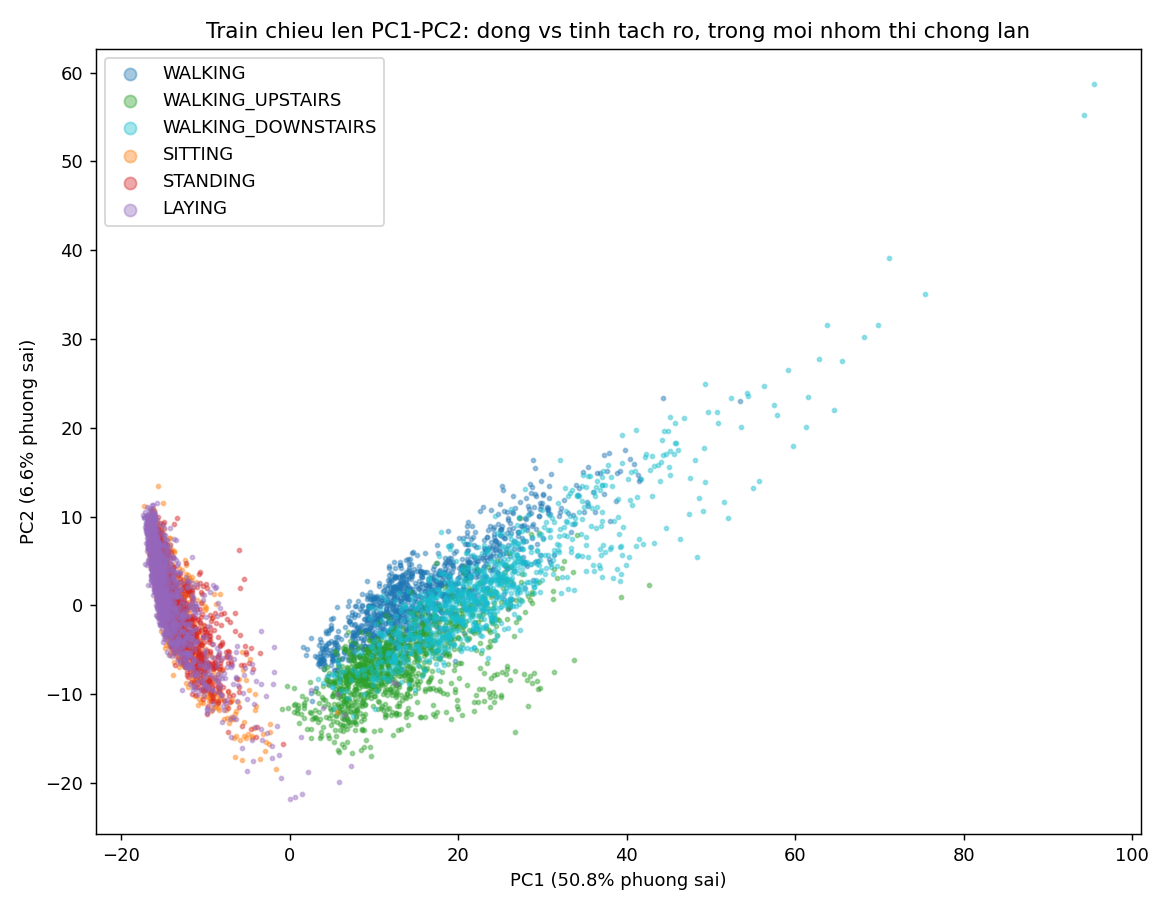

,PC1,PC2
WALKING,15.7950,1.0280
WALKING_UPSTAIRS,12.9100,-6.8630
WALKING_DOWNSTAIRS,23.8060,2.1210
SITTING,-14.0210,1.0290
STANDING,-13.5180,0.2200
LAYING,-14.2740,1.6970


In [5]:
scatter = P.run_pc_scatter(scaler, pca_full, Xtr, ytr, Xte, yte, groups)
display(Image(R / "pc1_pc2_scatter.png"))
pd.DataFrame(scatter["pc_trung_binh"]).T

**Đọc kết quả:**
* Chỉ **PC1** là đã tách gần hoàn hảo **động vs tĩnh**: accuracy CV 0,9965, test **0,9990**. Ba hoạt động di chuyển có
  PC1 trung bình +12,9 đến +23,8, ba hoạt động tĩnh khoảng −14.
* Nhưng **6 lớp với 2 chiều chỉ đạt 0,50** (CV). Trong nhóm tĩnh, ngồi/đứng/nằm chồng lên nhau (PC1 ≈ −14 cho cả ba).
  Trong nhóm động, ba kiểu đi chỉ tách được một phần, theo PC2 (lên cầu thang có PC2 ≈ −6,9).
* → 2 chiều đủ cho câu hỏi "người đang vận động hay không", nhưng không đủ để nhận đúng hoạt động.

## 8. Ý nghĩa của PC1

**Logic code (`run_pc1_analysis`):** `pca_full.components_[0]` là vector 561 hệ số (loading) của PC1. Hàm:
* sắp theo |hệ số| để lấy 10 đặc trưng gốc đóng góp nhiều nhất;
* cộng **bình phương hệ số** theo nhóm tín hiệu (phần trước dấu `-` trong tên, ví dụ `tBodyAccJerk`). Vì vector có độ
  dài 1, tổng bình phương = 100%, nên mỗi nhóm có một "tỉ trọng";
* đếm cần bao nhiêu đặc trưng để gom 50% tỉ trọng, xem PC1 có bị một vài cột chi phối không.

[TT-24]   PC1: can 159/561 dac trung de gom 50% trong so -> PC1 la tong hop RAT NHIEU cot, khong 1 cot nao chu dao


[TT-24]   Top 10 he so PC1: fBodyAcc-sma()(+0.059), fBodyAccJerk-sma()(+0.059), tBodyAccJerk-sma()(+0.059), fBodyGyro-sma()(+0.059), tBodyAccJerkMag-mean()(+0.058), tBodyAccJerkMag-sma()(+0.058), fBodyBodyAccJerkMag-mean()(+0.058), fBodyBodyAccJerkMag-sma()(+0.058), tBodyAccJerkMag-mad()(+0.058), tBodyAccJerkMag-std()(+0.058)


[TT-24]   Nhom tin hieu (% trong so PC1): fBodyAccJerk=16.9%, fBodyAcc=15.7%, fBodyGyro=13.1%, tBodyAccJerk=7.5%, tBodyAcc=7.2%, tBodyGyroJerk=6.9%


[TT-24]   Khong chuan hoa, PC1 bi chi phoi boi: fBodyAccJerk-entropy()-X(0.125), fBodyAccJerk-entropy()-Y(0.122), tBodyAccJerkMag-entropy()(0.121), fBodyAcc-entropy()-X(0.120), fBodyAccMag-entropy()(0.113)


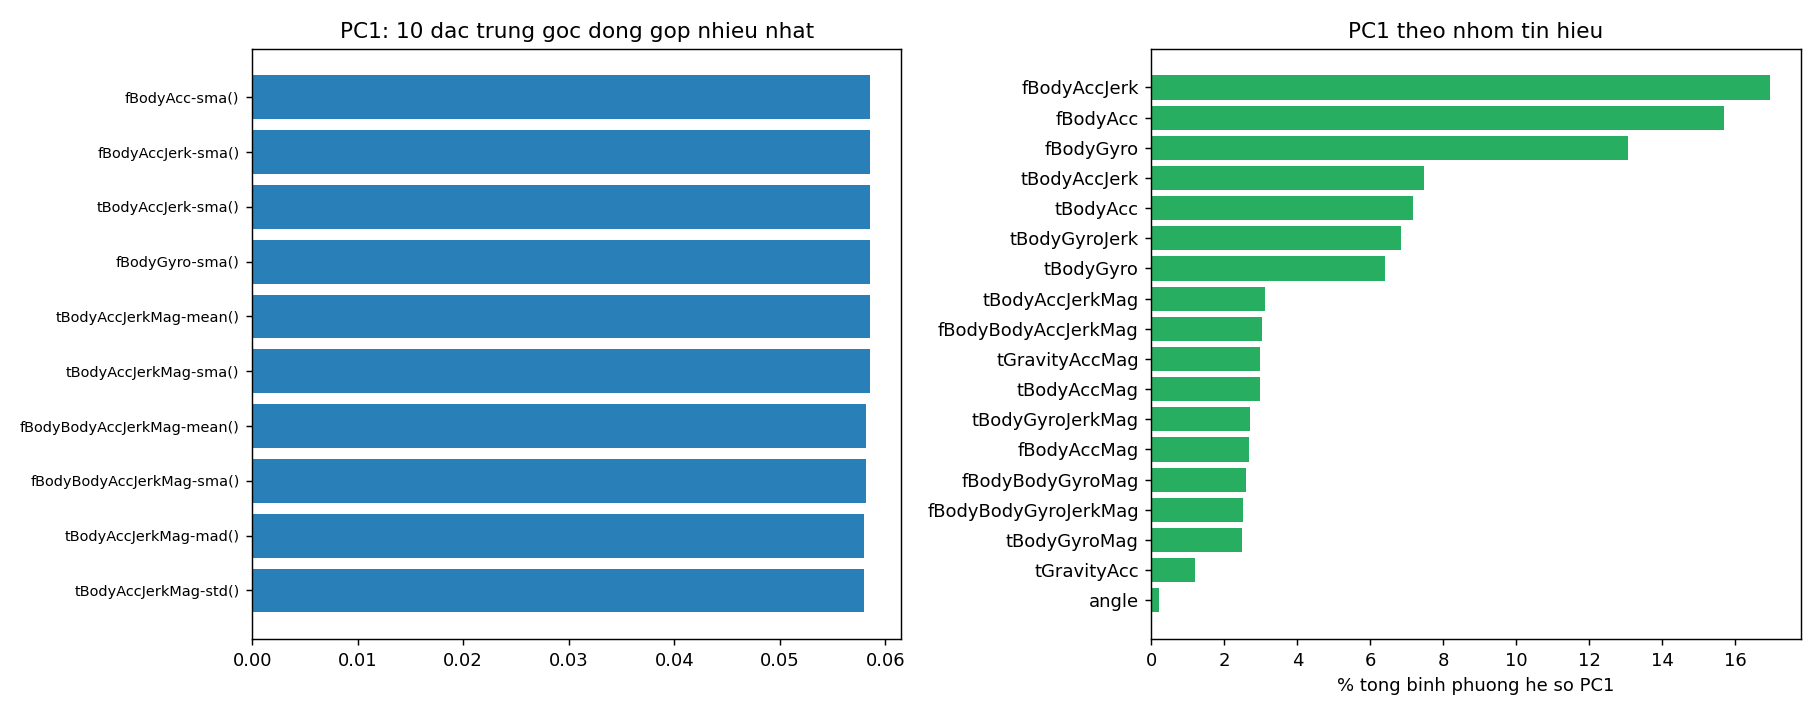

,dac_trung,he_so_PC1,nhom_tin_hieu
0,fBodyAcc-sma(),0.0586,fBodyAcc
1,fBodyAccJerk-sma(),0.0586,fBodyAccJerk
2,tBodyAccJerk-sma(),0.0585,tBodyAccJerk
3,fBodyGyro-sma(),0.0585,fBodyGyro
4,tBodyAccJerkMag-mean(),0.0585,tBodyAccJerkMag
5,tBodyAccJerkMag-sma(),0.0585,tBodyAccJerkMag
6,fBodyBodyAccJerkMag-mean(),0.0581,fBodyBodyAccJerkMag
7,fBodyBodyAccJerkMag-sma(),0.0581,fBodyBodyAccJerkMag
8,tBodyAccJerkMag-mad(),0.0580,tBodyAccJerkMag
9,tBodyAccJerkMag-std(),0.0580,tBodyAccJerkMag


fBodyAccJerk      16.9400
fBodyAcc          15.6800
fBodyGyro         13.0700
tBodyAccJerk       7.4600
tBodyAcc           7.1700
tBodyGyroJerk      6.8500
tBodyGyro          6.4000
tBodyAccJerkMag    3.1200
dtype: float64

In [6]:
pc1 = P.run_pc1_analysis(pca_full, pca_raw, feats)
display(Image(R / "pc1_phan_tich.png"))
display(pd.DataFrame(pc1["top10"]))
pd.Series(pc1["nhom_tin_hieu_%"]).head(8)

**Đọc kết quả — PC1 là "cường độ chuyển động":**
* 10 hệ số lớn nhất **gần như bằng nhau** (+0,058 đến +0,059) và **cùng dấu dương**: `sma()` (diện tích dưới tín hiệu),
  `mean/std/mad` của **độ giật (Jerk)** gia tốc, `fBodyGyro-sma()`. Đây đều là các đại lượng đo "cơ thể đang rung lắc
  mạnh cỡ nào".
* Cần tới **159/561 đặc trưng** mới gom được 50% tỉ trọng. PC1 là **trung bình của rất nhiều cột** cùng đo một hiện
  tượng, không có cột nào chủ đạo. Các nhóm lớn nhất: `fBodyAccJerk` 16,9%, `fBodyAcc` 15,7%, `fBodyGyro` 13,1%.
* Khớp với mục 7: PC1 cao thì đang vận động, thấp thì đứng yên. Đây là trường hợp **hiếm** PC1 có ý nghĩa vật lý rõ.
  Từ PC2 trở đi thì không còn diễn giải được như vậy (hạn chế "mất tính giải thích").
* Không chuẩn hoá thì PC1 bị chi phối bởi các cột `entropy()`, tức các cột có phương sai lớn nhất, đúng cạm bẫy của đề.

## 9. ⭐ Tiết kiệm được gì THẬT SỰ? Dung lượng, truyền dữ liệu, bộ nhớ model, phép tính

**Logic code (`run_cost_analysis` + `linear_cost`):** với mỗi cấu hình tính:
* **Dung lượng dữ liệu:** `số mẫu × số chiều × 8 byte` (float64).
* **Truyền dữ liệu:** mỗi cửa sổ 2,56 s chồng lấn 50%, tức một cửa sổ mới mỗi 1,28 s, **67.500 cửa sổ/ngày**. Nhân với
  `số chiều × 4 byte` (float32 trên vi điều khiển).
* **Bộ nhớ model** (float32), đếm tham số của pipeline: scaler `2×561`; PCA `K×561` (ma trận chiếu) `+ 561` (mean);
  LinearSVC `6×K + 6`. So với **64 KB** RAM.
* **Phép nhân–cộng (MAC) mỗi lần suy luận:** chuẩn hoá `561`, chiếu `561×K`, phân loại `6×K`.
* **Điểm mấu chốt:** PCA rồi LinearSVC là **hai phép tuyến tính liên tiếp** `W·(P·x)`, nên có thể **gộp** thành một ma
  trận `(W·P)` kích thước 6×561. Khi gộp, chi phí suy luận **bằng đúng** model gốc 561 chiều.
* So sánh thêm **RBF-SVM**: chi phí của nó ≈ `số vector hỗ trợ × số chiều`, nên giảm chiều giảm chi phí thật.

In [7]:
cost_lin, cost_rbf = P.run_cost_analysis(Xtr, Xte, ytr, k_sweet, k95)
display(cost_lin)
cost_rbf

[TT-24]     Goc 561 chieu                du lieu   46.2 MB | truyen  151.5 MB/ngay | model    17.6 KB (64KB: True) | MAC 3,927 (gop: 3,927)


[TT-24]     PCA K=102 (95% phuong sai)   du lieu    8.4 MB | truyen   27.5 MB/ngay | model   232.5 KB (64KB: False) | MAC 58,395 (gop: 3,927)


[TT-24]     PCA K=200 (diem ngot)        du lieu   16.5 MB | truyen   54.0 MB/ngay | model   449.6 KB (64KB: False) | MAC 113,961 (gop: 3,927)


[TT-24]     PCA K=50                     du lieu    4.1 MB | truyen   13.5 MB/ngay | model   117.3 KB (64KB: False) | MAC 28,911 (gop: 3,927)


[TT-24]     LDA 5 chieu                  du lieu    0.4 MB | truyen    1.4 MB/ngay | model    17.7 KB (64KB: True) | MAC 3,396 (gop: 3,927)


[TT-24]     RBF-SVM 561 chieu            SV=2332 MAC=1,308,252 model=5,110 KB fit=8.19s du doan=2.750 ms/mau


[TT-24]     RBF-SVM PCA K=200            SV=2324 MAC=577,000 model=2,254 KB fit=3.05s du doan=1.018 ms/mau


[TT-24]     RBF-SVM PCA K=50             SV=2313 MAC=143,700 model=561 KB fit=1.70s du doan=0.558 ms/mau


,cau_hinh,so_chieu,dung_luong_du_lieu_MB_float64,truyen_moi_cua_so_bytes,truyen_moi_ngay_MB,tham_so_model,bo_nho_model_KB,vua_64KB_RAM,MAC_moi_lan_suy_luan,MAC_neu_gop_W_P
0,Goc 561 chieu,561,46.2219,2244,151.4700,4494,17.5547,True,3927,3927
1,PCA K=102 (95% phuong sai),102,8.4040,408,27.5400,59523,232.5117,False,58395,3927
2,PCA K=200 (diem ngot),200,16.4784,800,54.0000,115089,449.5664,False,113961,3927
3,PCA K=50,50,4.1196,200,13.5000,30039,117.3398,False,28911,3927
4,LDA 5 chieu,5,0.4120,20,1.3500,4524,17.6719,True,3396,3927


,cau_hinh,so_chieu,so_vector_ho_tro,MAC_moi_lan_suy_luan,bo_nho_model_KB,thoi_gian_fit_s,thoi_gian_du_doan_ms_moi_mau
0,RBF-SVM 561 chieu,561,2332,1308252,"5,110.3594",8.1894,2.7497
1,RBF-SVM PCA K=200,200,2324,577000,"2,253.9062",3.0484,1.0178
2,RBF-SVM PCA K=50,50,2313,143700,561.3281,1.7032,0.5580


**Đọc kết quả:**

| Cấu hình | Dữ liệu (10.299 mẫu) | Truyền/ngày | Model (float32) | Vừa 64 KB? | MAC/lần | MAC nếu gộp W·P |
|---|---|---|---|---|---|---|
| Gốc 561 chiều | 46,2 MB | 151,5 MB | **17,6 KB** | ✅ | 3.927 | 3.927 |
| PCA K = 102 (95%) | 8,4 MB | 27,5 MB | 232,5 KB | ❌ | 58.395 | 3.927 |
| PCA K = 200 (điểm ngọt) | 16,5 MB (−64%) | 54,0 MB (−64%) | 449,6 KB | ❌ | 113.961 | 3.927 |
| PCA K = 50 | 4,1 MB | 13,5 MB | 117,3 KB | ❌ | 28.911 | 3.927 |
| **LDA 5 chiều** | **0,4 MB (−99%)** | **1,4 MB (−99%)** | **17,7 KB** | ✅ | 3.396 | — |

1. **Với bộ phân loại tuyến tính chạy trên chip, PCA KHÔNG tiết kiệm mà còn tốn hơn.** Ma trận chiếu K×561 nặng 450 KB
   ở K = 200, vượt xa 64 KB, và cần thêm 29 lần phép tính. Gộp `W·P` thì đưa về đúng 17,6 KB và 3.927 MAC như model gốc,
   tức không lợi gì. Con số "tiết kiệm ~90% tính toán" của đề **không đúng** cho trường hợp này.
2. **PCA tiết kiệm thật ở khâu truyền và lưu trữ**: nếu vòng tay gửi đặc trưng về điện thoại hoặc máy chủ, K = 200 giảm
   băng thông 151,5 → 54,0 MB/ngày (−64%). Nhưng muốn chiếu được thì vẫn phải chứa ma trận chiếu trên chip (450 KB).
3. **LDA 5 chiều thắng ở mọi cột**: 1,4 MB/ngày, 17,7 KB, 3.396 MAC, và accuracy không giảm (mục 11).
4. **RBF-SVM là nơi PCA giảm chi phí suy luận thật** (bảng dưới): chi phí ∝ số vector hỗ trợ (≈ 2.300) × số chiều.

   | RBF-SVM | Vector hỗ trợ | MAC/lần | Model | Dự đoán (ms/mẫu) |
   |---|---|---|---|---|
   | 561 chiều | 2.332 | 1.308.252 | 5.110 KB | 2,75 |
   | PCA K = 200 | 2.324 | 577.000 (−56%) | 2.254 KB | 1,02 |
   | PCA K = 50 | 2.313 | 143.700 (−89%) | 561 KB | 0,56 |

   Số vector hỗ trợ gần như không đổi, nên chi phí giảm gần tỉ lệ với số chiều. Nhưng ngay cả K = 50 vẫn cần 561 KB,
   quá lớn cho chip 64 KB. Mô hình phi tuyến kiểu này không hợp với thiết bị này dù có PCA.

## 10. Sai số tái tạo theo K

**Logic code (`run_reconstruction`):** với mỗi K, fit PCA trên train đã chuẩn hoá, rồi
`X̂ = inverse_transform(transform(X))` (nén rồi giải nén). Sai số là `mean((X − X̂)²)`. Vì dữ liệu đã chuẩn hoá (mỗi cột
phương sai ≈ 1), MSE này ≈ **tỉ lệ phương sai bị mất**. Tính trên cả train và test (người chưa gặp).

[TT-24]     K=  2: MSE train=0.4264 test=0.3917 (mat 42.6% / 45.6% phuong sai)


[TT-24]     K=  5: MSE train=0.3544 test=0.3387 (mat 35.4% / 39.4% phuong sai)


[TT-24]     K= 10: MSE train=0.2918 test=0.2880 (mat 29.2% / 33.5% phuong sai)


[TT-24]     K= 25: MSE train=0.2024 test=0.2049 (mat 20.2% / 23.8% phuong sai)


[TT-24]     K= 50: MSE train=0.1248 test=0.1324 (mat 12.5% / 15.4% phuong sai)


...

[TT-24]     K=100: MSE train=0.0511 test=0.0578 (mat 5.1% / 6.7% phuong sai)


[TT-24]     K=150: MSE train=0.0189 test=0.0231 (mat 1.9% / 2.7% phuong sai)


[TT-24]     K=200: MSE train=0.0064 test=0.0080 (mat 0.6% / 0.9% phuong sai)


[TT-24]     K=300: MSE train=0.0009 test=0.0012 (mat 0.1% / 0.1% phuong sai)


[TT-24]     K=400: MSE train=0.0000 test=0.0000 (mat 0.0% / 0.0% phuong sai)


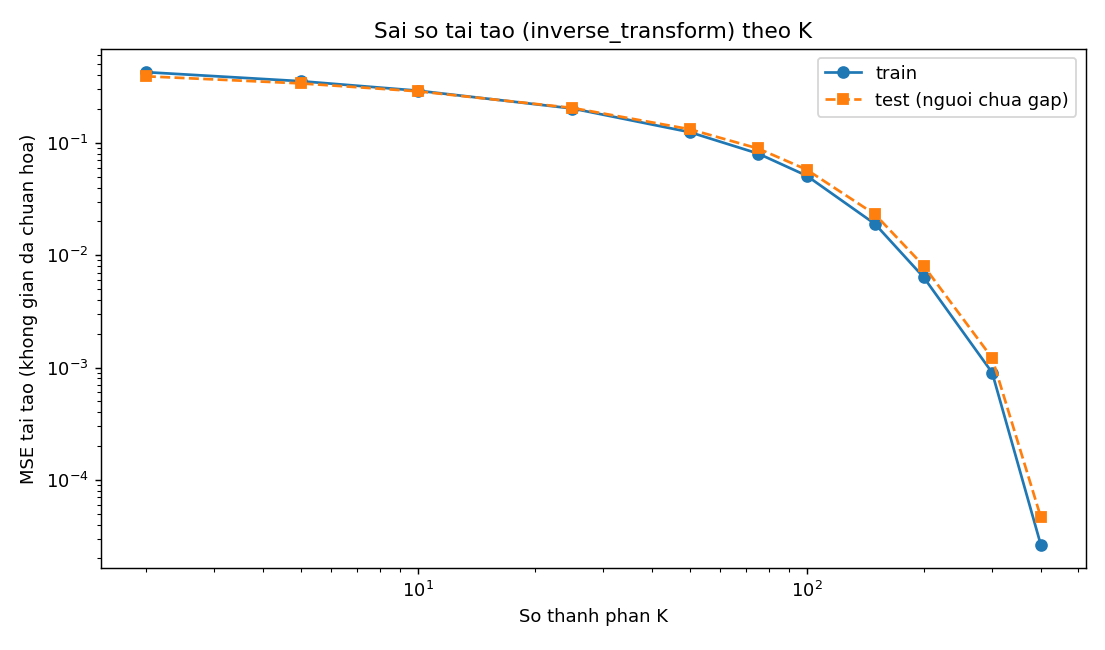

,K,MSE_tai_tao_train,MSE_tai_tao_test,phuong_sai_mat_train_%,phuong_sai_mat_test_%
0,2,0.4264,0.3917,42.6381,45.5655
1,5,0.3544,0.3387,35.4395,39.4026
2,10,0.2918,0.2880,29.1844,33.5085
3,25,0.2024,0.2049,20.2405,23.8355
4,50,0.1248,0.1324,12.4816,15.4079
5,75,0.0805,0.0892,8.0452,10.3779
6,100,0.0511,0.0578,5.1085,6.7282
7,150,0.0189,0.0231,1.8946,2.6827
8,200,0.0064,0.0080,0.6364,0.9361
9,300,0.0009,0.0012,0.0901,0.1414


In [8]:
recon = P.run_reconstruction(scaler, Xtr, Xte)
display(Image(R / "sai_so_tai_tao.png"))
recon

**Đọc kết quả:** sai số tái tạo giảm đều: K = 50 mất 12,5% (train) / 15,4% (test); K = 100 mất 5,1% / 6,7%; K = 200 mất 0,6% /
0,9%; K ≥ 400 gần như 0 (561 cột chỉ có ~400 hướng độc lập thực sự). Test luôn hơi cao hơn train: các trục chính được
học từ 21 người, nên với người mới nén kém hơn một chút. Đây cũng là cơ sở cho phát hiện bất thường (mục mở rộng 3).

## 11a. PCA vs SelectKBest vs LDA: cách giảm chiều nào tốt nhất cho MODEL?

**Logic code (`run_supervised_comparison`):** cùng khung `Scaler → [giảm chiều] → LinearSVC`, cùng `GroupKFold`, chỉ đổi
bước giảm chiều:
* **PCA** (không giám sát): giữ hướng có phương sai lớn.
* **SelectKBest(f_classif)**: **chọn** K cột gốc có F-score ANOVA cao nhất. Đây là chọn đặc trưng, không tạo đặc trưng mới.
* **LDA** (có giám sát): tìm tối đa `số lớp − 1 = 5` hướng **tách các lớp tốt nhất** (tỉ số phương sai giữa lớp / trong lớp).

[TT-24]     PCA                      K= 10: acc CV=0.8298+-0.051 test=0.8331


[TT-24]     SelectKBest(f_classif)   K= 10: acc CV=0.7518+-0.047 test=0.7567


[TT-24]     PCA                      K= 25: acc CV=0.8761+-0.051 test=0.8921


[TT-24]     SelectKBest(f_classif)   K= 25: acc CV=0.8683+-0.028 test=0.8738


[TT-24]     PCA                      K= 50: acc CV=0.8958+-0.049 test=0.9118


...

[TT-24]     SelectKBest(f_classif)   K=100: acc CV=0.9183+-0.031 test=0.9365


[TT-24]     PCA                      K=200: acc CV=0.9230+-0.033 test=0.9515


[TT-24]     SelectKBest(f_classif)   K=200: acc CV=0.9264+-0.040 test=0.9471


[TT-24]     LDA (co giam sat)        K=  2: acc CV=0.6613+-0.031 test=0.6142


[TT-24]     LDA (co giam sat)        K=  5: acc CV=0.9467+-0.033 test=0.9627


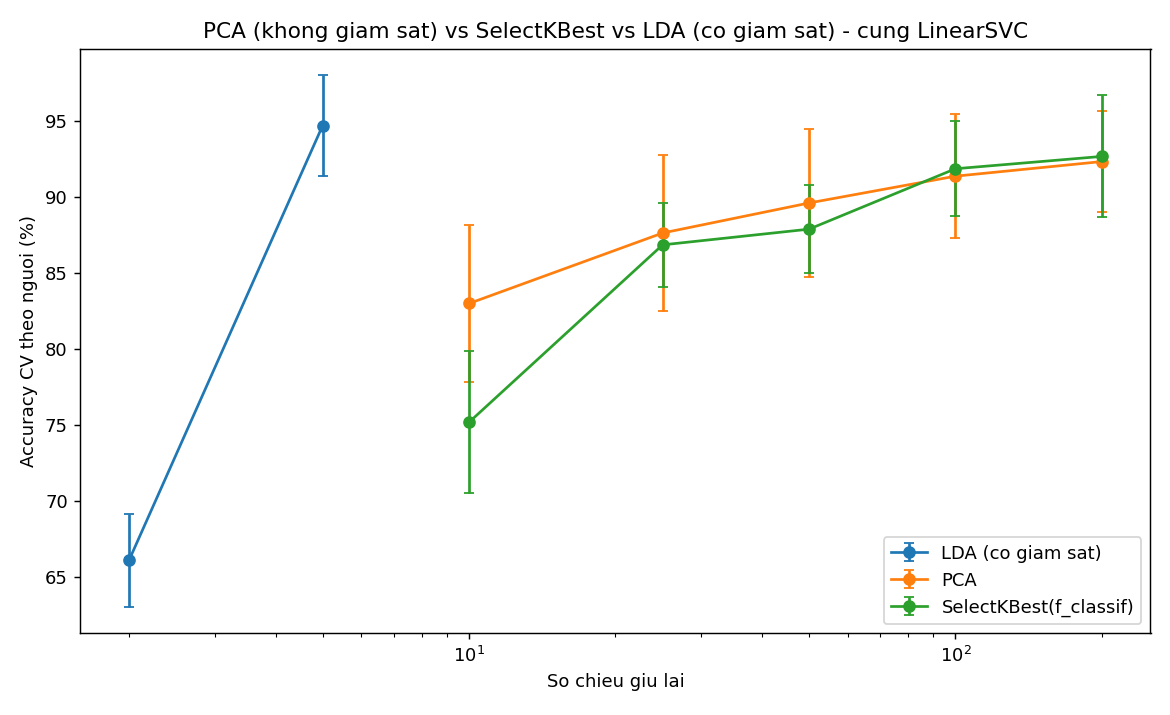

phuong_phap,LDA (co giam sat),PCA,SelectKBest(f_classif)
K,,,
2,0.6613,NaN,NaN
5,0.9467,NaN,NaN
10,NaN,0.8298,0.7518
25,NaN,0.8761,0.8683
50,NaN,0.8958,0.8786
100,NaN,0.9134,0.9183
200,NaN,0.9230,0.9264


In [9]:
comp = P.run_supervised_comparison(Xtr, ytr, Xte, yte, groups)
display(Image(R / "so_sanh_giam_chieu.png"))
comp.pivot(index="K", columns="phuong_phap", values="acc_cv")

**Đọc kết quả (accuracy CV):**

| K | 10 | 25 | 50 | 100 | 200 |
|---|---|---|---|---|---|
| PCA | **0,830** | **0,876** | **0,896** | 0,913 | 0,923 |
| SelectKBest | 0,752 | 0,868 | 0,879 | **0,918** | **0,926** |

| **LDA** | 2 chiều: 0,661 | **5 chiều: 0,947** (test 0,963) |
|---|---|---|

* Ở số chiều **nhỏ (10–50)**, PCA hơn SelectKBest (+7,8 điểm ở K = 10): mỗi PC gom thông tin của hàng trăm cột, còn
  SelectKBest chỉ giữ được từng cột lẻ, lại toàn các cột trùng thông tin. Từ K = 100 trở lên hai cách ngang nhau.
* **LDA 5 chiều vượt cả mô hình đủ 561 chiều** (CV 0,947 so với 0,930; test 0,9627 bằng nhau). LDA biết nhãn nên dồn
  đúng thông tin phân biệt hoạt động vào 5 chiều. PCA không biết nhãn nên tốn hàng trăm chiều để giữ cả những biến động
  không liên quan (ví dụ khác biệt giữa người với người).
* → **Bài học chính:** khi mục tiêu là phân loại, giảm chiều có giám sát (LDA) hiệu quả hơn hẳn PCA. PCA hợp hơn khi
  không có nhãn, hoặc khi cần nén chung cho nhiều tác vụ.

## 11b. t-SNE và UMAP: chỉ để trực quan hoá

**Logic code (`run_embedding_comparison`):** lấy ngẫu nhiên 3.000 mẫu train (t-SNE chậm với 7.352 điểm), chuẩn hoá, nhúng
xuống 2D bằng PCA, t-SNE (`perplexity=30`) và UMAP. Để có con số so sánh "độ tách lớp" của mỗi hình, chấm **5-NN
cross-validation ngay trên toạ độ 2D**. Đây là chỉ số mô tả hình, không phải model: t-SNE/UMAP đã nhìn toàn bộ 3.000
điểm khi nhúng, và **không có `transform` ổn định cho dữ liệu mới**, nên không thể dùng làm bước tiền xử lý.

[TT-24]     PCA   :    0.1s  5-NN trong 2D = 0.565


[TT-24]     t-SNE :   19.9s  5-NN trong 2D = 0.937


[TT-24]     UMAP  :   62.7s  5-NN trong 2D = 0.907


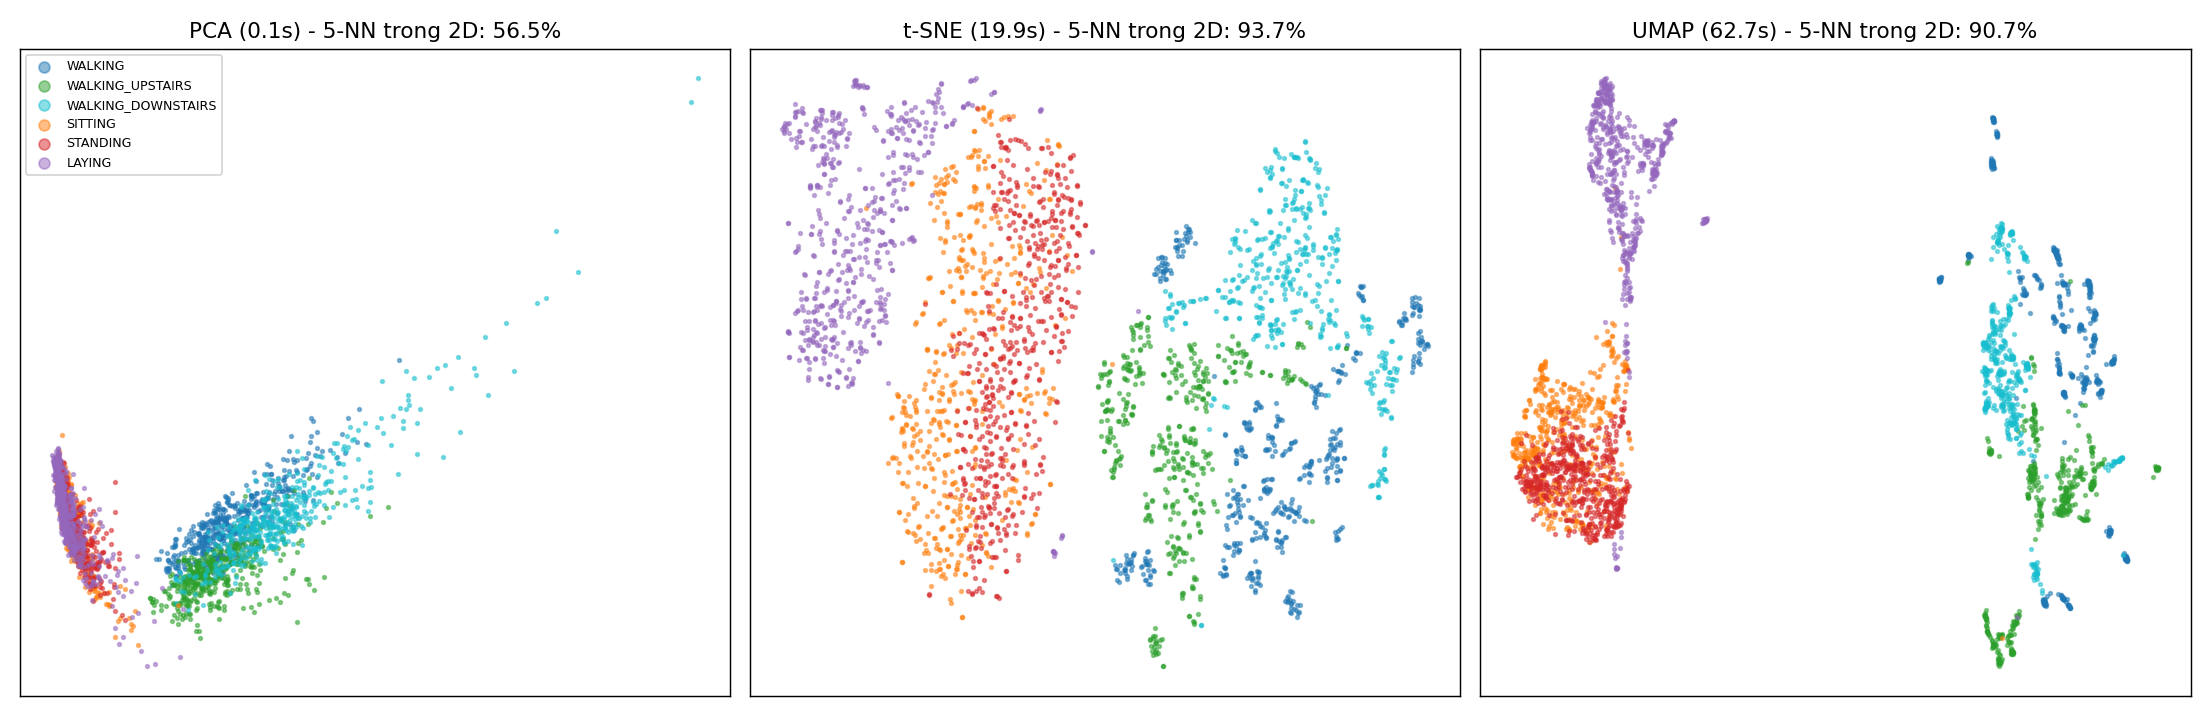

,phuong_phap,thoi_gian_s,acc_5NN_trong_2D,co_transform_cho_du_lieu_moi
0,PCA,0.1197,0.5650,True
1,t-SNE,19.8928,0.9373,False
2,UMAP,62.7042,0.9067,False


In [10]:
emb = P.run_embedding_comparison(Xtr, ytr, scaler)
display(Image(R / "pca_tsne_umap.png"))
emb

**Đọc kết quả:** trong 2D, t-SNE tách lớp tốt nhất (5-NN 0,937), UMAP 0,907, còn PCA 2D chỉ 0,565. Các phương pháp phi tuyến
giữ được **cấu trúc lân cận cục bộ** (ngồi/đứng/nằm thành cụm riêng), còn PCA chỉ giữ hướng phương sai toàn cục. Đổi lại,
chúng chậm hơn hàng trăm lần (PCA 0,1 s so với t-SNE ~20 s, UMAP ~60 s, có cả thời gian biên dịch numba) và không chiếu
được người mới. Dùng chúng để **nhìn** dữ liệu, không dùng để **nén** cho model.

## Mở rộng 1. Kernel PCA (RBF)

**Logic code (`run_kernel_pca`):** thay `PCA(50)` bằng `KernelPCA(50, kernel="rbf")` trong cùng pipeline, so sánh bằng
`GroupKFold`. Kernel PCA làm PCA trong không gian đặc trưng ngầm của kernel RBF (bắt được quan hệ phi tuyến), nhưng muốn
chiếu một điểm mới thì phải tính kernel với **toàn bộ 7.352 điểm train**.

In [11]:
kpca = P.run_kernel_pca(Xtr, ytr, Xte, yte, groups)
kpca

[TT-24]     PCA tuyen tinh                 K=50: acc CV=0.8958 test=0.9118 fit=1.6s du doan=0.008 ms/mau


[TT-24]     Kernel PCA (RBF, gamma=1/561)  K=50: acc CV=0.8831 test=0.9179 fit=4.7s du doan=0.535 ms/mau


,phuong_phap,K,acc_cv,acc_test,thoi_gian_fit_s,thoi_gian_du_doan_ms_moi_mau,phai_luu_toan_bo_train_de_transform
0,PCA tuyen tinh,50,0.8958,0.9118,1.5787,0.0077,False
1,"Kernel PCA (RBF, gamma=1/561)",50,0.8831,0.9179,4.7138,0.5354,True


**Đọc kết quả:** Kernel PCA **không** tốt hơn PCA tuyến tính (CV 0,883 so với 0,896, test 0,918 so với 0,912: chênh lệch
nằm trong nhiễu). Nhưng nó đắt hơn nhiều: fit lâu gấp ~3 lần, dự đoán chậm gấp hàng chục đến hàng trăm lần (~70 lần ở lần chạy này,
~400 lần ở lần chạy script), vì phải tính kernel với cả tập train. Với 561
đặc trưng đã được kỹ sư tính sẵn, quan hệ đủ "tuyến tính" để PCA thường là đủ.

## Mở rộng 2. IncrementalPCA: mô phỏng luồng cảm biến không vừa RAM

**Logic code (`run_incremental_pca`):** đưa dữ liệu vào **từng lô 500 mẫu** bằng `partial_fit`, giống luồng cảm biến đổ về
theo thời gian, rồi so với PCA fit một lần. Độ giống nhau của hai không gian con đo bằng **cos các góc chính** (singular
values của `P_pca · P_ipcaᵀ`): bằng 1 nghĩa là trùng khít.

In [12]:
ipca = P.run_incremental_pca(scaler, Xtr, ytr, Xte, yte, k_sweet)
pd.Series(ipca)

[TT-24]     IncrementalPCA K=200, 15 batch x 500: phuong sai 99.32% (PCA 99.36%), cos goc chinh TB=0.9885 min=0.0186, acc test 0.9542 vs 0.9515, RAM/batch 2.2 MB vs 16.5 MB


K                             200.0000
batch_size                    500.0000
so_batch                       15.0000
phuong_sai_PCA_%               99.3636
phuong_sai_IncrementalPCA_%    99.3211
cos_goc_chinh_trung_binh        0.9885
cos_goc_chinh_nho_nhat          0.0186
acc_test_PCA                    0.9515
acc_test_IncrementalPCA         0.9542
bo_nho_moi_batch_MB             2.2440
bo_nho_ca_ma_tran_MB           16.4979
thoi_gian_IncrementalPCA_s     11.9948
dtype: float64

**Đọc kết quả:** 15 lô × 500 mẫu, mỗi lô chỉ cần **2,2 MB** RAM thay vì 16,5 MB cho cả ma trận. IncrementalPCA giữ 99,32%
phương sai (PCA 99,36%) và accuracy test tương đương (0,9542 so với 0,9515). Cos góc chính trung bình 0,989, nhưng góc nhỏ
nhất ≈ 0,02: vài hướng ở **đuôi** (phương sai rất nhỏ, gần bằng nhau) bị xoay. Các hướng đó không mang thông tin quan
trọng nên accuracy không bị ảnh hưởng.

## Mở rộng 3. Phát hiện bất thường bằng sai số tái tạo

**Logic code (`run_anomaly_detection`):** với mỗi hoạt động, **bỏ hẳn nó khỏi train**, fit Scaler + PCA(102) trên 5 hoạt động
còn lại, rồi tính sai số tái tạo từng mẫu test. Nếu hoạt động "lạ" có sai số cao hơn các hoạt động đã biết, PCA phát hiện
được nó. Đo bằng AUC, và tỉ lệ bắt được ở ngưỡng = phân vị 95 sai số trên train (tức chấp nhận ~5% báo động giả).

In [13]:
anomaly = P.run_anomaly_detection(Xtr, ytr, Xte, yte, k95)
anomaly

[TT-24]     Bo LAYING             khoi train: AUC=0.998  bat duoc 100.0% bao dong gia 7.1% (nguong p95)


[TT-24]     Bo WALKING_DOWNSTAIRS khoi train: AUC=0.904  bat duoc 70.7% bao dong gia 10.4% (nguong p95)


[TT-24]     Bo WALKING            khoi train: AUC=0.819  bat duoc 23.4% bao dong gia 7.1% (nguong p95)


[TT-24]     Bo WALKING_UPSTAIRS   khoi train: AUC=0.756  bat duoc 11.9% bao dong gia 8.3% (nguong p95)


[TT-24]     Bo STANDING           khoi train: AUC=0.447  bat duoc 0.9% bao dong gia 7.4% (nguong p95)


[TT-24]     Bo SITTING            khoi train: AUC=0.393  bat duoc 3.5% bao dong gia 7.2% (nguong p95)


,hoat_dong_chua_gap,AUC_sai_so_tai_tao,sai_so_TB_hoat_dong_moi,sai_so_TB_hoat_dong_da_biet,ty_le_bat_duoc_o_nguong_p95_train_%,bao_dong_gia_o_nguong_p95_train_%
5,LAYING,0.9975,0.4327,0.0562,100.0000,7.1369
2,WALKING_DOWNSTAIRS,0.9040,0.2023,0.0580,70.7143,10.3680
0,WALKING,0.8193,0.0989,0.0543,23.3871,7.0583
1,WALKING_UPSTAIRS,0.7558,0.0812,0.0561,11.8896,8.3199
4,STANDING,0.4470,0.0465,0.0572,0.9398,7.4120
3,SITTING,0.3935,0.0464,0.0574,3.4623,7.2068


**Đọc kết quả:**
* **Nằm (LAYING) bị phát hiện gần hoàn hảo** (AUC 0,998, bắt 100%): tư thế nằm làm hướng trọng lực khác hẳn mọi hoạt động khác.
* **Xuống cầu thang** AUC 0,904 (bắt 70,7%); đi bộ / lên cầu thang thì trung bình (AUC 0,76–0,82).
* **Ngồi và đứng: AUC < 0,5**, không phát hiện được. Bỏ "ngồi" khỏi train thì PCA học từ "đứng" vẫn tái tạo tốt "ngồi" vì
  hai tư thế gần như giống nhau với cảm biến ở thắt lưng.
* → Sai số tái tạo chỉ bắt được bất thường **khác biệt về cấu trúc tín hiệu**. Nó không thay được model có giám sát
  (nối sang ý tưởng VAE ở KT-19).

## Model cuối và ma trận nhầm lẫn (test, dùng 1 lần)

**Logic code (`build_final_models`):** fit 3 pipeline trên **toàn bộ train**, chấm trên test: PCA K = 200 (điểm ngọt, lưu
`models/pca_pipeline.joblib`, model đề yêu cầu), gốc 561 chiều (đối chiếu), và LDA 5 chiều (lưu
`models/lda_pipeline.joblib`, khuyến nghị cho thiết bị).

[TT-24]     PCA K=200 + LinearSVC        acc test=0.9515  F1: WALKING=0.962, WALKING_=0.957, WALKING_=0.982, SITTING=0.894, STANDING=0.922, LAYING=0.994


[TT-24]     Goc 561 chieu + LinearSVC    acc test=0.9627  F1: WALKING=0.984, WALKING_=0.970, WALKING_=0.983, SITTING=0.910, STANDING=0.933, LAYING=0.996


[TT-24]     LDA 5 chieu + LinearSVC      acc test=0.9627  F1: WALKING=0.982, WALKING_=0.972, WALKING_=0.993, SITTING=0.907, STANDING=0.925, LAYING=1.000


[TT-24]   Da luu models/pca_pipeline.joblib (model de bai yeu cau) va models/lda_pipeline.joblib


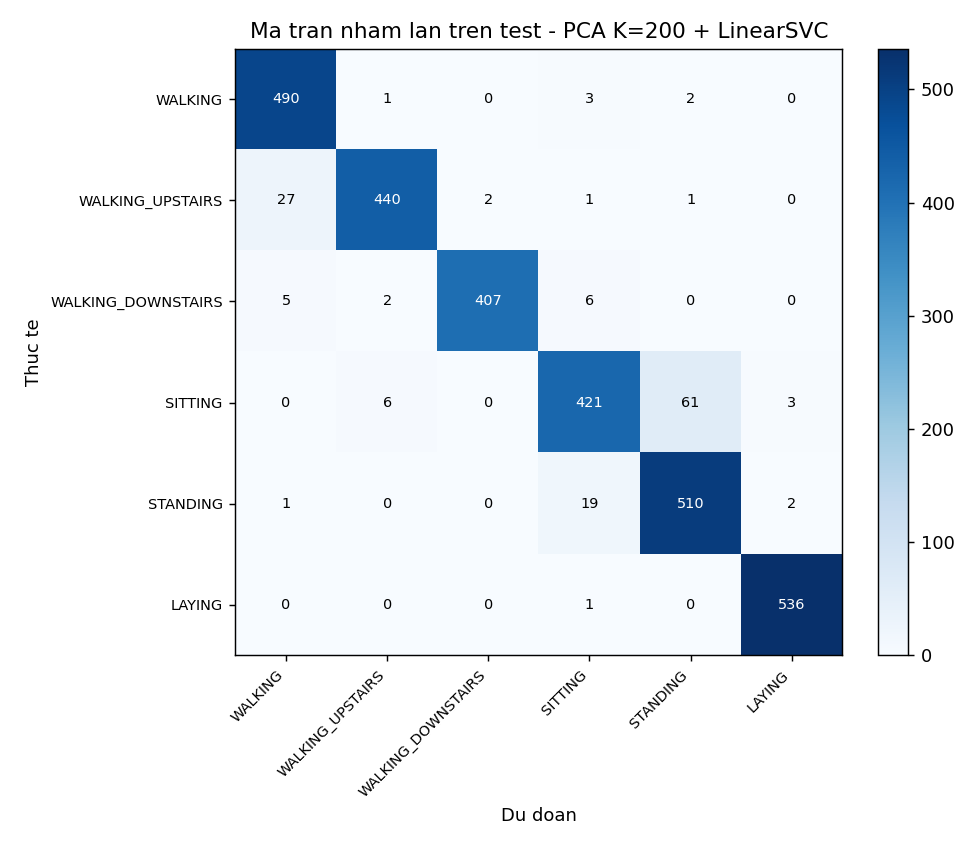

,acc_test,WALKING,WALKING_UPSTAIRS,WALKING_DOWNSTAIRS,SITTING,STANDING,LAYING
PCA K=200 + LinearSVC,0.9515,0.9617,0.9565,0.9819,0.8938,0.9222,0.9944
Goc 561 chieu + LinearSVC,0.9627,0.9840,0.9703,0.9831,0.9104,0.9332,0.9963
LDA 5 chieu + LinearSVC,0.9627,0.9820,0.9723,0.9928,0.9075,0.9249,1.0000


In [14]:
final = P.build_final_models(Xtr, ytr, Xte, yte, k_sweet)
display(Image(R / "confusion_matrix_pca.png"))
pd.DataFrame({k: {"acc_test": v["acc_test"], **v["f1_theo_lop"]} for k, v in final.items()}).T

**Đọc kết quả (test, 9 người chưa gặp):**

| Model | Acc test | F1 SITTING | F1 STANDING | F1 LAYING | F1 các kiểu đi |
|---|---|---|---|---|---|
| PCA K = 200 + LinearSVC | 0,9515 | 0,894 | 0,922 | 0,994 | 0,957–0,982 |
| Gốc 561 + LinearSVC | 0,9627 | 0,910 | 0,933 | 0,996 | 0,970–0,984 |
| **LDA 5 + LinearSVC** | **0,9627** | 0,907 | 0,925 | **1,000** | 0,972–0,993 |

Lỗi tập trung ở **ngồi ↔ đứng**, cặp mà cả PC1–PC2 lẫn phát hiện bất thường đều không tách được. PCA K = 200 mất 1,1 điểm
so với gốc, chủ yếu ở hai lớp này: thông tin phân biệt ngồi/đứng nằm một phần ở các hướng phương sai nhỏ bị cắt đi.

In [15]:
P.save_summary(var_table=var_table, k95=k95, tradeoff=tradeoff, k_sweet=k_sweet, scatter=scatter, pc1=pc1,
               cost_lin=cost_lin, cost_rbf=cost_rbf, recon=recon, comp=comp, emb=emb, kpca=kpca, ipca=ipca,
               anomaly=anomaly, final=final, pca_full=pca_full)

[TT-24]   Da luu reports/tom_tat.json


## Tổng kết

| Câu hỏi | Trả lời (số đo) |
|---|---|
| Bao nhiêu chiều giữ 95% phương sai? | **102** (giảm 81,8%). Không chuẩn hoá thì 67, nhưng là ảo |
| Điểm ngọt (mất ≤ 1 điểm accuracy, chọn bằng CV theo người) | **K = 200** (−64% số chiều): CV 0,923 so với 0,930; test 0,952 so với 0,963 |
| 2 chiều có tách được 6 hoạt động? | Không (0,50). Nhưng **PC1 một mình tách động/tĩnh 99,9%** |
| PC1 là gì? | "Cường độ chuyển động": trung bình đều của hàng trăm đặc trưng độ giật / năng lượng |
| Tiết kiệm thật? | Truyền dữ liệu / lưu trữ −64% (K = 200). **Không** giảm tính toán cho model tuyến tính trên chip (ma trận chiếu 450 KB > 64 KB) |
| Cách giảm chiều tốt nhất cho nhận dạng? | **LDA 5 chiều**: −99% số chiều, accuracy test bằng model đủ 561 chiều, model 17,7 KB |

**Hạn chế:** PC mất tính giải thích (trừ PC1). PCA chỉ bắt quan hệ **tuyến tính** và **không biết nhãn**, nên giữ phương
sai ≠ giữ thông tin phân loại. Điểm ngọt nhạy với nhiễu CV (±3–5 điểm giữa các fold). Phân tích chi phí chưa tính phần lớn
nhất trên thiết bị thật là **tính 561 đặc trưng** từ tín hiệu thô (FFT, jerk...).